In [1]:
import pandas as pd

In [2]:
data_base = pd.read_excel('../results/processed_data and results/PROCESS_GE2000_BASE.xlsx', sheet_name=None)

data_harvested_area = data_base['harvested area']
data_planted_area = data_base['planted area']
data_production = data_base['production']
data_census_irrigated_harvested = data_base['census irrigated harvested']
data_census_overall_harvested = data_base['census overall harvested']
data_water_applied = data_base['water applied']


In [3]:
data_applications = pd.read_excel('../results/processed_data and results/PROCESS_GE2000_APPLICATIONS.xlsx', sheet_name=None)
print(data_applications)

data_HERBICIDE = data_applications['CHEMICAL, HERBICIDE (TOTAL)']
data_INSECTICIDE = data_applications['CHEMICAL, INSECTICIDE (TOTAL)']
data_OTHERCHEMICAL = data_applications['CHEMICAL, OTHER (TOTAL)']
data_NITROGEN = data_applications['FERTILIZER (NITROGEN)']
data_PHOSPHATE = data_applications['FERTILIZER (PHOSPHATE)']
data_POTASH = data_applications['FERTILIZER (POTASH)']
data_SULFUR = data_applications['FERTILIZER (SULFUR)']

print(data_production, data_HERBICIDE,data_INSECTICIDE )

{'CHEMICAL, FUNGICIDE (TOTAL)':        state_name     2007    2017     2019    2021
0         ALABAMA      NaN     NaN   5000.0     NaN
1        ARKANSAS  16000.0  7000.0  15000.0     NaN
2      CALIFORNIA   1000.0     NaN      NaN     NaN
3         GEORGIA      NaN  9000.0  31000.0     NaN
4     MISSISSIPPI   3000.0     NaN      NaN     NaN
5        MISSOURI      NaN  9000.0      NaN  5000.0
6  NORTH CAROLINA  15000.0     NaN      NaN     NaN
7  SOUTH CAROLINA  13000.0     NaN      NaN     NaN, 'CHEMICAL, HERBICIDE (TOTAL)':         state_name        2007        2015        2017      2019        2021
0          ALABAMA    941000.0    997000.0   1422000.0   1900000   1177000.0
1          ARIZONA         NaN    353000.0         NaN    329000         NaN
2         ARKANSAS   2399000.0    752000.0   1681000.0   2210000   1239000.0
3       CALIFORNIA    565000.0    295000.0         NaN    609000         NaN
4          GEORGIA   3163000.0   4370000.0   4409000.0   4445000   3427000.0
5     

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
font_dirs = ["/content/drive/MyDrive/NU work/Font"]  # The path to the custom font file./content/Arial.ttf
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

print(font_files)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
font_manager.get_font_names()


plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 8

[]


In [5]:
data_energy = pd.read_excel('../results/processed_data and results/Processed_Energy.xlsx',
                            usecols=[0,1,2,4,5], nrows=24,
                            names=['year','diesel','diesel tax', 'elec', 'total price'])

data_energy = data_energy.set_index('year')

# ADD allocation factor for cotton lint
data_total_price = data_energy['total price']*0.824
print(data_total_price)


data_planted_area_sum = data_planted_area.sum(axis=0)
print(data_planted_area_sum)

data_production_sum = data_production.sum(axis=0)
print(data_production_sum)

data_total_price_per_bale = data_total_price*data_planted_area_sum/data_production_sum
print(data_total_price_per_bale)
#convert per bale to per 1000kg, 1000kg = 4.593*480lb
data_energy['price per 1000kg'] = data_total_price_per_bale*4.593

# convert gallon to liter: 1 gallon = 3.785 liter
# exclude the federal tax (0.244) and state tax
data_energy['diesel liter'] = (data_energy['diesel']-data_energy['diesel tax']-0.244)/3.785

year
2023    39.63440
2022    45.46008
2021    31.72400
2020    24.23384
2019    28.81528
2018    36.76688
2017    35.65448
2016    31.46032
2015    35.83576
2014    52.74424
2013    52.71128
2012    53.14800
2011    51.87080
2010    42.63376
2009    33.59448
2008    50.49472
2007    40.26064
2006    32.13600
2005    31.30376
2004    23.59112
2003    20.09736
2002    25.84888
2001    30.06776
2000    30.46328
Name: total price, dtype: float64
Category    ALABAMAARIZONAARKANSASCALIFORNIAFLORIDAGEORGIA...
2023                                                 10232500
2022                                                 13749000
2021                                                 11206500
2020                                                 12086000
2019                                                 13722700
2018                                                 14081300
2017                                                 12717500
2016                                                 1007

      diesel  diesel tax    elec  total price price per 1000kg  diesel liter
year                                                                        
2023   4.214      0.3347  0.0804        48.10       149.809593      0.960449
2022   4.989      0.3218  0.0832        55.17        198.42174      1.168613
2021   3.287      0.3089  0.0718        38.50        93.184981      0.722351
2020   2.551      0.2809  0.0667        29.41        92.092736      0.535297
2019   3.056      0.2786  0.0681        34.97        91.208029      0.669326
2018   3.178      0.2654  0.0692        44.62       129.466602      0.705046
2017   2.650      0.2760  0.0688        43.27        99.540249      0.562748
2016   2.304      0.2506  0.0676        38.18         84.77586      0.478045
2015   2.707      0.2504  0.0691        43.49        109.58223      0.584571
2014   3.825      0.2256  0.0710        64.01        165.49308      0.886499
2013   3.922      0.2190  0.0689        63.97       195.175919      0.913871

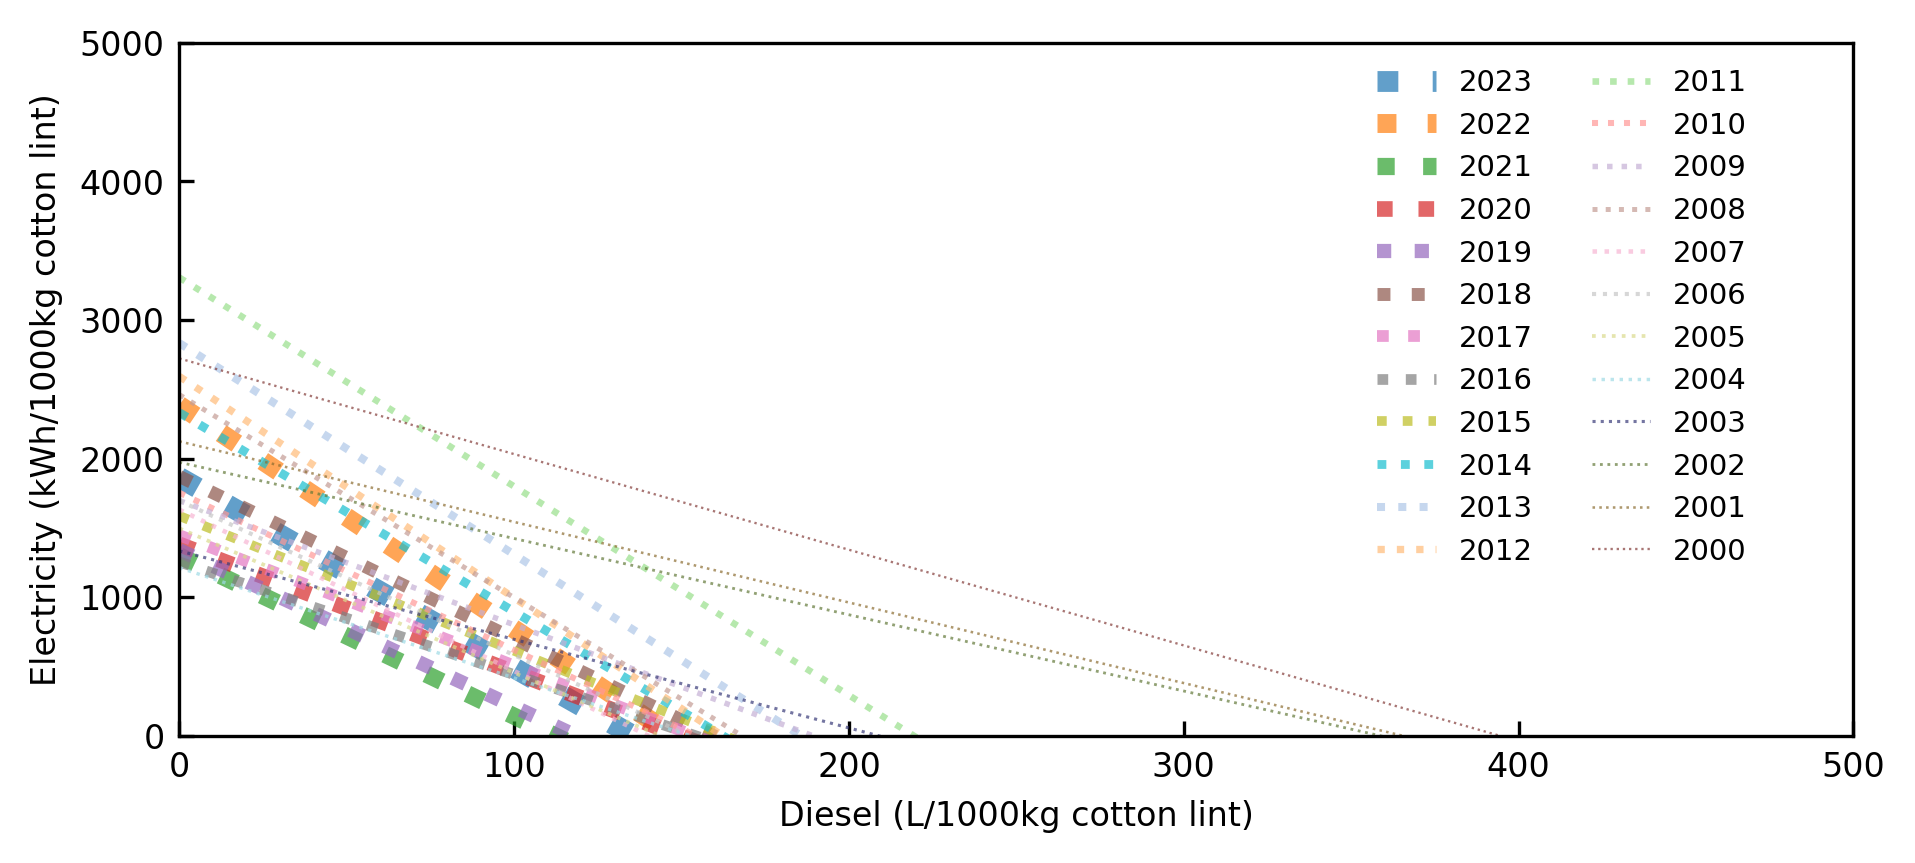

In [6]:
print(data_energy)

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



x = np.linspace(0, 600, 400)

plt.figure(figsize=(7.2, 3))

linestyles = [':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b',
          '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8', '#ffbb78',
          '#98df8a', '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d3', '#c7c7c7',
          '#dbdb8d', '#9edae5', '#393b79', '#637939', '#8c6d31', '#843c39']
i = 5
coefficients = []
k = 0
for index, row in data_energy.iterrows():
    a, b, c = 1.15*row['diesel liter'], row['elec'], row['price per 1000kg']
    coefficients.append((a, b, c))
    y = (c - a * x) / b

    linestyle = linestyles[k % len(linestyles)]

    plt.plot(x, y, label=index, linewidth=i, color=colors[k],
             linestyle=linestyle, alpha=0.7)
    i =i/1.1
    k += 1
plt.xlim(0, 500)
plt.ylim(0, 5000)  # Adjust as needed based on the range of your data
plt.xlabel('Diesel (L/1000kg cotton lint)')
plt.ylabel('Electricity (kWh/1000kg cotton lint)')
plt.legend(bbox_to_anchor=(0.7, 1), loc='upper left', fontsize=7, frameon=False, ncol=2)

plt.savefig('../outputs/energy_national/figure_linearprogram.tiff',dpi=300, bbox_inches='tight')
plt.show()


[(np.float64(215.97815106340997), np.float64(-1103.754245322788)), (np.float64(260.81341522857997), np.float64(-1719.690683319689)), (np.float64(107.04273275811731), np.float64(392.77521138973594)), (np.float64(215.19499353741026), np.float64(-1092.995409260672)), (np.float64(-3.761211539919914), np.float64(1914.9740438872648)), (np.float64(96.15826321207706), np.float64(542.3035241253581)), (np.float64(108.68598362799187), np.float64(370.20061288180244)), (np.float64(69.20725955717995), np.float64(912.5501480882536)), (np.float64(752.9252448736703), np.float64(-8480.208616951124)), (np.float64(639.6762590746192), np.float64(-6924.42037261605)), (np.float64(325.4480636571725), np.float64(-2607.6264603372824)), (np.float64(1084.3127582233697), np.float64(-13032.733250626165)), (np.float64(46.04172369329224), np.float64(1230.792895398235)), (np.float64(34.91888975792926), np.float64(1383.5958027111053)), (np.float64(660.3859937553049), np.float64(-7208.925894075466)), (np.float64(110.703

[107.63134748 646.33949148]
[107.04273276  96.15826321 108.68598363  69.20725956  46.04172369
  34.91888976 110.70368571  64.59396333 110.71022428 112.56876219
  72.03352412 145.0400262  115.86661289 139.04945746 140.99203607
 124.38231212  30.09526537 131.55276652  95.74780777 137.48425424
 143.03455761 107.63134748  38.64307506  25.23740173  12.73107286
  23.6342868  115.44047269 103.86300674  96.84704606 132.13192879
  16.48916906  26.88712296  37.91228671   1.11512783 143.38307995
  63.32153273 100.77654819 151.27894634  82.52389143 143.58515239
  48.64781421  37.41944859 107.48118886 146.84720559 105.75444349
 160.91380956 161.07039159 103.202086    23.75673527  77.7254371
  75.42472831 161.51806783 117.58131427 125.08075033  40.37439375
  24.21763975 180.65911564 169.0671384   88.13599292  75.08434189
  13.22539052 127.72618919  98.63379785 131.23339721  59.10092167
  46.09134167 139.25353559 127.65874696  71.40710062  23.81769928
  84.51293337 134.57089786 140.7787992  136.50888

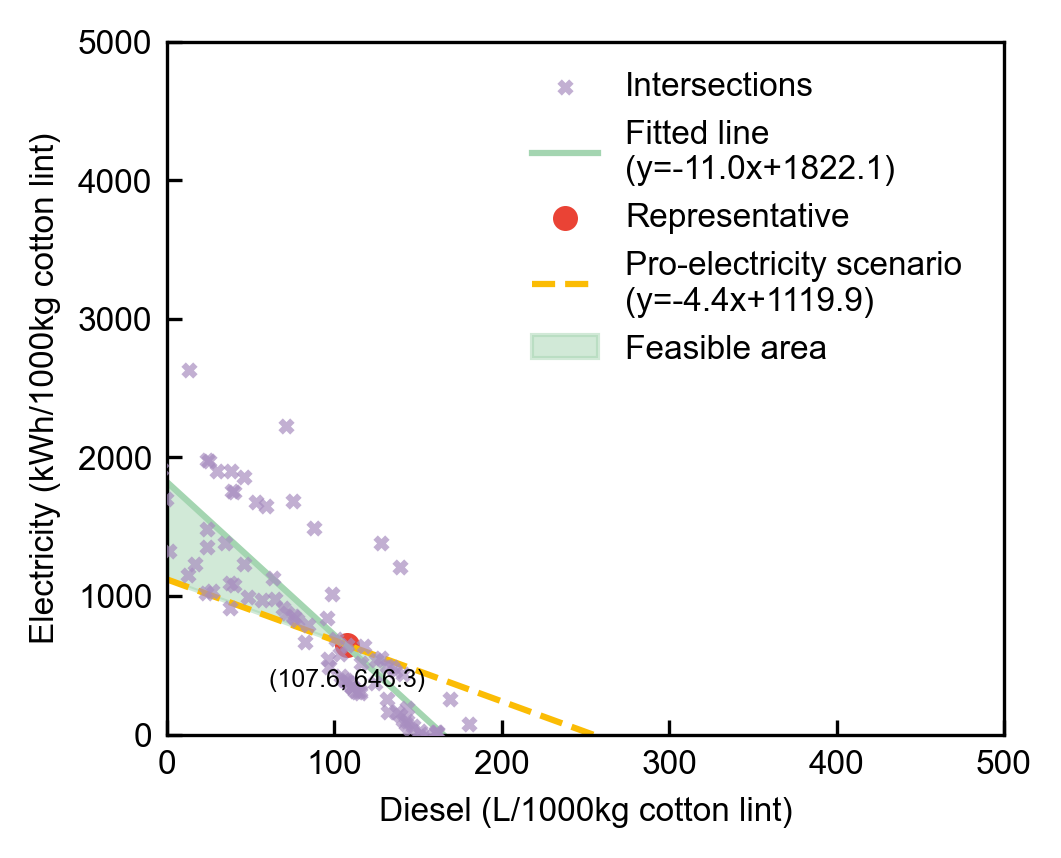

In [7]:
def find_intersection(coef1, coef2):
    a1, b1, c1 = coef1
    a2, b2, c2 = coef2

    denominator = a1 * b2 - a2 * b1

    if denominator == 0:
        return None  # Lines are parallel, no intersection

    x = (c1 * b2 - c2 * b1) / denominator
    y = (c1 - a1 * x) / b1  # You could also use coef2 here

    return (x, y)

from itertools import combinations
import matplotlib


intersections = []
for coef1, coef2 in combinations(coefficients, 2):
    intersection = find_intersection(coef1, coef2)
    if intersection is not None:
        intersections.append(intersection)

print(intersections)


x_intersections, y_intersections = zip(*intersections)




matplotlib.rcParams['font.family'] = "sans-serif"
plt.rcParams['font.sans-serif'] = "Arial"

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] =8

plt.figure(figsize=(3.6, 3))
plt.scatter(x_intersections, y_intersections, color='#A88EC0', marker='x', s=8, zorder=3, alpha=0.7, label='Intersections')

plt.xlim(0, 500)
plt.ylim(0, 5000)



def filter_points_within_limits(intersections):
    filtered_points = [(x, y) for x, y in intersections if 0 <= x <= 500 and 0 <= y <= 5000]
    return filtered_points

filtered_intersections = filter_points_within_limits(intersections)


from scipy.spatial.distance import pdist, squareform

filtered_intersections = np.array(filtered_intersections)  # Convert list of tuples to a numpy array for easier handling

dist_matrix = squareform(pdist(filtered_intersections))

average_distances = dist_matrix.sum(axis=1) / (len(filtered_intersections) - 1)

closest_index = np.argmin(average_distances)

closest_point = filtered_intersections[closest_index]

print(closest_point)


x_filtered_intersections, y_filtered_intersections = zip(*filtered_intersections)

slope, intercept = np.polyfit(np.array(x_filtered_intersections), np.array(y_filtered_intersections), 1)
print(np.array(x_filtered_intersections), np.array(y_filtered_intersections))
fit_line = slope * np.array(x_filtered_intersections) + intercept

plt.plot(np.arange(0,400,1), slope * np.arange(0,400,1) + intercept, linestyle='-',
         label=f'Fitted line \n(y={slope:.1f}x+{intercept:.1f})', color='#A4D5B1')




pro_elec_intercept = closest_point[1] + 4.4 * closest_point[0]
plt.scatter(closest_point[0],closest_point[1], color='#EA4335', s=25, label='Representative')

plt.plot(np.arange(0,400,1), -4.4 * np.arange(0,400,1) + pro_elec_intercept, linestyle='--',
         label=f'Pro-electricity scenario \n(y=-4.4x+{pro_elec_intercept:.1f})', color='#FBBC04')

plt.fill_between(np.arange(0, 130, 1), -4.4 * np.arange(0,130,1) + pro_elec_intercept,
                  slope * np.arange(0,130,1) + intercept, color='#A4D5B1', alpha=0.5, label='Feasible area')

print(slope, intercept)


# plt.scatter(closest_point[0],closest_point[1] , color='#EA4335', s=25, label='Representative')
plt.annotate(f'({closest_point[0]:.1f}, {closest_point[1]:.1f})', (closest_point[0],closest_point[1]), textcoords="offset points", xytext=(0,-10), ha='center', fontsize=6)


plt.xlabel('Diesel (L/1000kg cotton lint)')
plt.ylabel('Electricity (kWh/1000kg cotton lint)')
plt.legend(bbox_to_anchor=(0.4, 1), loc='upper left', frameon=False, ncol=1)
plt.savefig('../outputs/energy_national/figure_intersections.tiff',dpi=300, bbox_inches='tight')
plt.show()

        state_name        2007        2015        2017      2019        2021
0          ALABAMA    941000.0    997000.0   1422000.0   1900000   1177000.0
1          ARIZONA         NaN    353000.0         NaN    329000         NaN
2         ARKANSAS   2399000.0    752000.0   1681000.0   2210000   1239000.0
3       CALIFORNIA    565000.0    295000.0         NaN    609000         NaN
4          GEORGIA   3163000.0   4370000.0   4409000.0   4445000   3427000.0
5        LOUISIANA    992000.0         NaN         NaN   1297000         NaN
6      MISSISSIPPI   2132000.0   1495000.0   3017000.0   3116000   1754000.0
7         MISSOURI    995000.0    590000.0   1037000.0   1126000    944000.0
8   NORTH CAROLINA   1479000.0   1448000.0   1378000.0   2002000   1607000.0
9         OKLAHOMA         NaN         NaN    765000.0   2501000   1449000.0
10  SOUTH CAROLINA    535000.0    739000.0         NaN   1153000         NaN
11       TENNESSEE   1482000.0    511000.0   1266000.0   1711000   1282000.0

([<matplotlib.axis.XTick at 0x135225f70>,
 [Text(0, 0, 'HERBICIDE'),
  Text(1, 0, 'INSECTICIDE'),
  Text(2, 0, 'OTHERCHEMICAL'),
  Text(3, 0, 'NITROGEN'),
  Text(4, 0, 'PHOSPHATE'),
  Text(5, 0, 'POTASH'),
  Text(6, 0, 'SULFUR')])

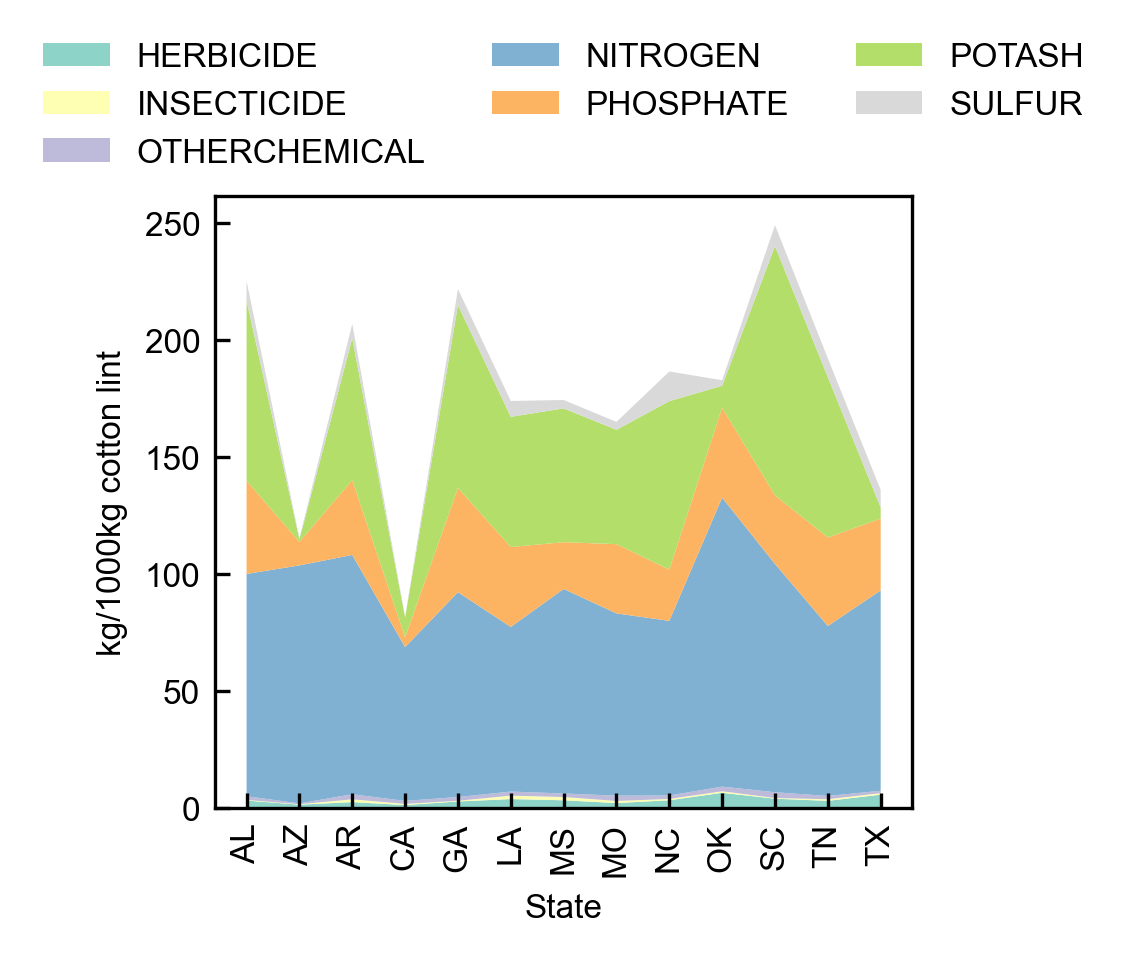

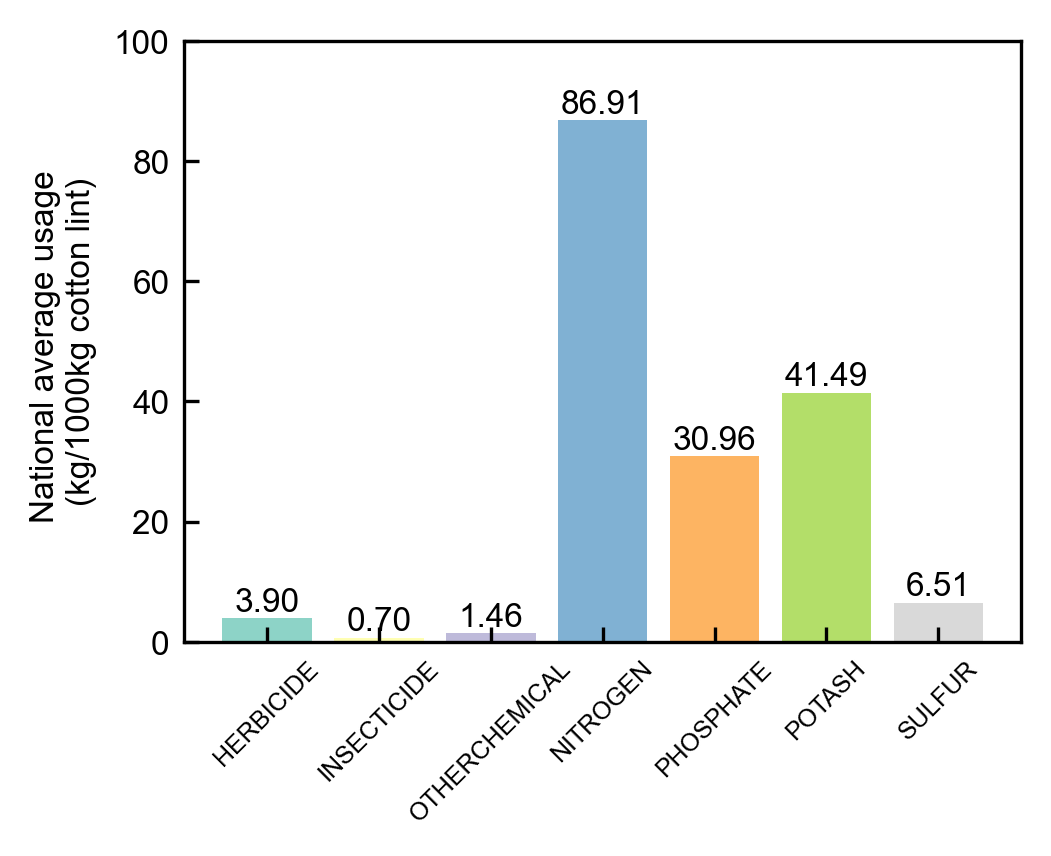

In [8]:
data_production_2019 = data_production[[2015,2019]].drop([4, 6, 10, 16]).reset_index(drop=True)
print(data_HERBICIDE)

# allocation number for cotton lint: 0.824
data_unit_HERBICIDE = data_HERBICIDE[[2015,2019]]/data_production_2019*0.824
data_unit_INSECTICIDE = data_INSECTICIDE[[2015,2019]]/data_production_2019*0.824
data_unit_OTHERCHEMICAL = data_OTHERCHEMICAL[[2015,2019]]/data_production_2019*0.824
data_unit_NITROGEN = data_NITROGEN[[2015,2019]]/data_production_2019*0.824
data_unit_PHOSPHATE = data_PHOSPHATE[[2015,2019]]/data_production_2019*0.824
data_unit_POTASH = (data_POTASH[[2015,2019]]/data_production_2019).interpolate(axis=1)*0.824
data_unit_SULFUR = (data_SULFUR[[2015,2019]]/data_production_2019).interpolate(axis=1)*0.824



cmap = plt.get_cmap('Set3')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

x = range(13)

# convert lb/bale = lb/480lb, lb/480lb*2.08 = kg/1000kg
y = np.vstack([data_unit_HERBICIDE[2019]*2.08, data_unit_INSECTICIDE[2019]*2.08,data_unit_OTHERCHEMICAL[2019]*2.08,
              data_unit_NITROGEN[2019]*2.08, data_unit_PHOSPHATE[2019]*2.08,data_unit_POTASH[2019]*2.08,data_unit_SULFUR[2019]*2.08])
print(y)

plt.figure(figsize=(3, 3))
plt.stackplot(x, y, colors=colors, labels=['HERBICIDE', 'INSECTICIDE','OTHERCHEMICAL','NITROGEN',
                            'PHOSPHATE','POTASH','SULFUR'])
plt.ylabel('kg/1000kg cotton lint')
plt.xlabel('State')

plt.subplots_adjust(bottom=0.2)

plt.xticks(x, ['AL', 'AZ', 'AR', 'CA', 'GA', 'LA', 'MS','MO','NC', 'OK','SC', 'TN', 'TX'], rotation=90)
plt.legend(bbox_to_anchor=(0.5, 1.3), loc='upper center', frameon=False, ncol=3)
plt.savefig('../outputs/energy_national/chemical_states.tiff',dpi=300, bbox_inches='tight')

def culculate_average(data):
  return sum(data*data_production_2019[2019])/sum(data_production_2019[2019])*2.08

x = range(7)
y = [culculate_average(data_unit_HERBICIDE[2019]), culculate_average(data_unit_INSECTICIDE[2019]),
     culculate_average(data_unit_OTHERCHEMICAL[2019]),culculate_average(data_unit_NITROGEN[2019]),
     culculate_average(data_unit_PHOSPHATE[2019]),culculate_average(data_unit_POTASH[2019]),
     culculate_average(data_unit_SULFUR[2019])]
print(y)

plt.figure(figsize=(3.6, 2.6))
bars = plt.bar(x, y, color=colors, label=['HERBICIDE', 'INSECTICIDE','OTHERCHEMICAL','NITROGEN','PHOSPHATE','POTASH','SULFUR'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', ha='center', va='bottom', fontsize=8, color='black')


plt.yticks(np.arange(0, 101, step=20))

plt.ylabel('National average usage \n(kg/1000kg cotton lint)')
plt.xticks(x, ['HERBICIDE', 'INSECTICIDE','OTHERCHEMICAL','NITROGEN','PHOSPHATE','POTASH','SULFUR'], rotation=45,fontsize=6)




Nitrogen Usage by State (kg/1000kg cotton lint):
--------------------------------------------------
AL: 95.03
AZ: 101.74
AR: 102.31
CA: 65.76
GA: 87.57
LA: 70.38
MS: 87.44
MO: 77.92
NC: 74.65
OK: 123.54
SC: 97.59
TN: 72.66
TX: 85.68
--------------------------------------------------
National Average Nitrogen Usage: 86.91 kg/1000kg cotton lint



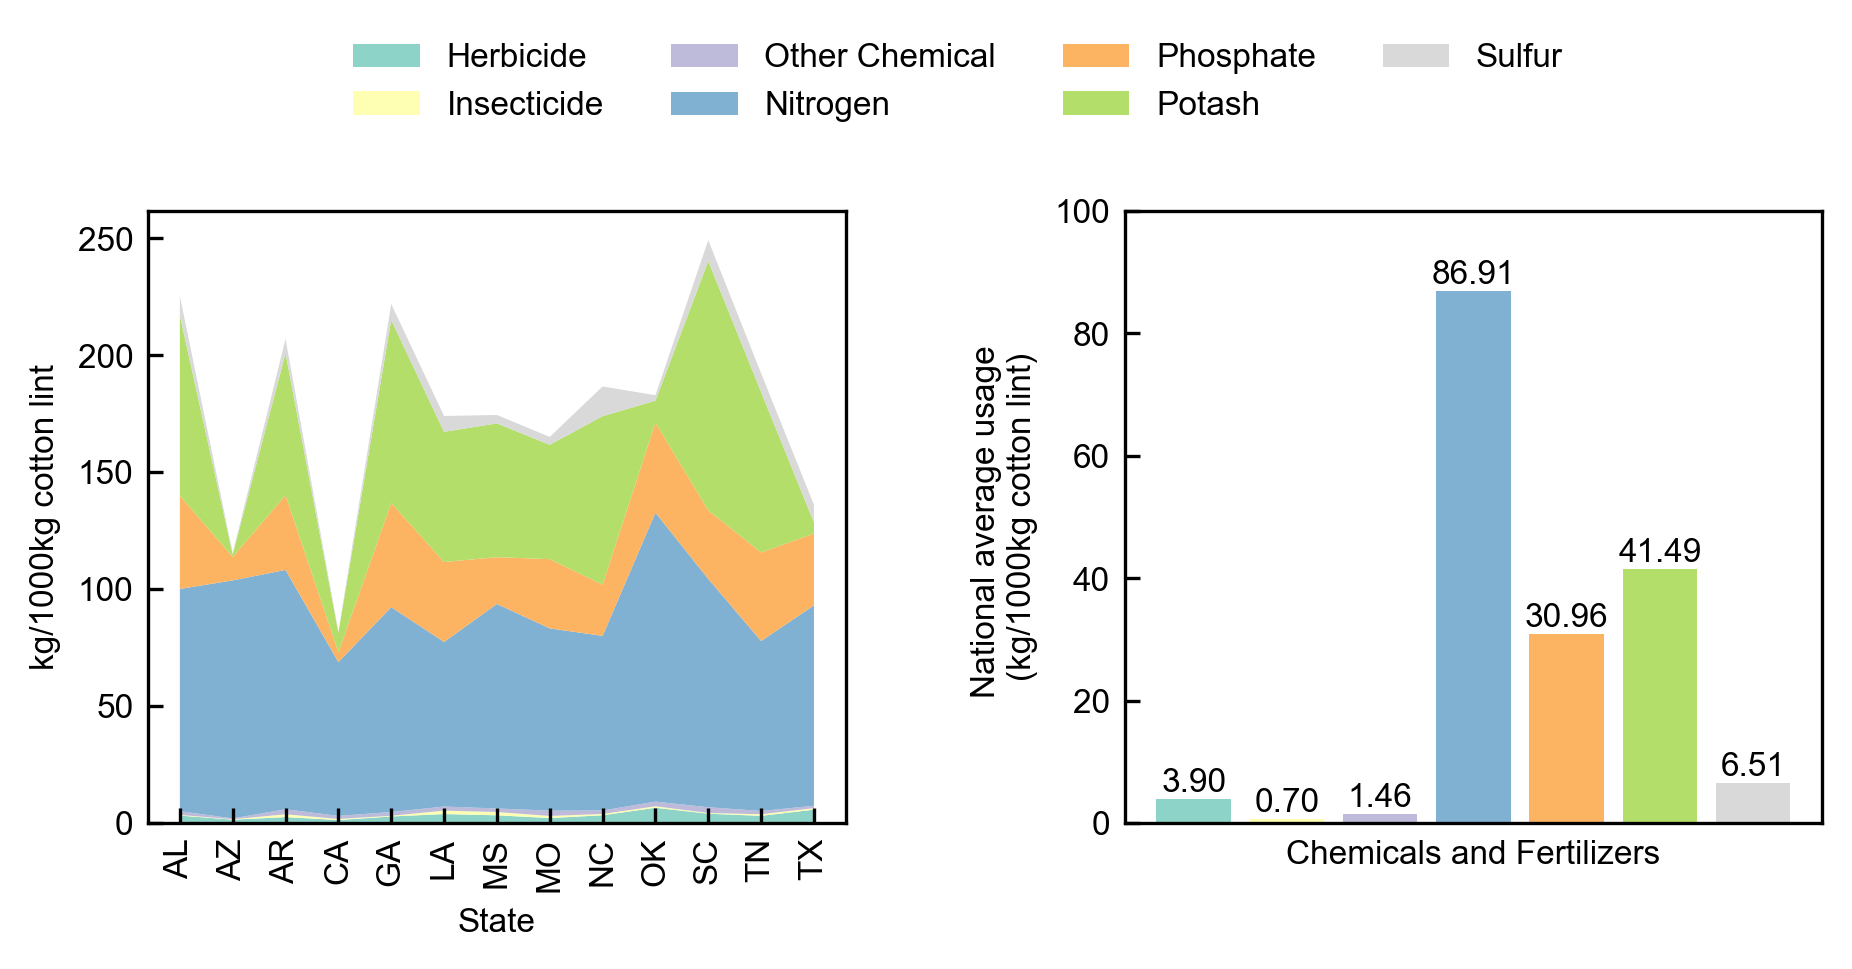

In [9]:
import numpy as np
import matplotlib.pyplot as plt

cmap = plt.get_cmap('Set3')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

x1 = range(13)
y1 = np.vstack([data_unit_HERBICIDE[2019]*2.08, data_unit_INSECTICIDE[2019]*2.08, data_unit_OTHERCHEMICAL[2019]*2.08,
                data_unit_NITROGEN[2019]*2.08, data_unit_PHOSPHATE[2019]*2.08, data_unit_POTASH[2019]*2.08, data_unit_SULFUR[2019]*2.08])

states = ['AL', 'AZ', 'AR', 'CA', 'GA', 'LA', 'MS', 'MO', 'NC', 'OK', 'SC', 'TN', 'TX']
nitrogen_usage = data_unit_NITROGEN[2019]*2.08

print("Nitrogen Usage by State (kg/1000kg cotton lint):")
print("-" * 50)
for i, state in enumerate(states):
    print(f"{state}: {nitrogen_usage[i]:.2f}")
print("-" * 50)

x2 = range(7)
def calculate_average(data):
    return sum(data * data_production_2019[2019]) / sum(data_production_2019[2019]) * 2.08

y2 = [calculate_average(data_unit_HERBICIDE[2019]), calculate_average(data_unit_INSECTICIDE[2019]),
      calculate_average(data_unit_OTHERCHEMICAL[2019]), calculate_average(data_unit_NITROGEN[2019]),
      calculate_average(data_unit_PHOSPHATE[2019]), calculate_average(data_unit_POTASH[2019]),
      calculate_average(data_unit_SULFUR[2019])]

print(f"National Average Nitrogen Usage: {y2[3]:.2f} kg/1000kg cotton lint")
print()

fig, axs = plt.subplots(1, 2, figsize=(7.2, 3))

axs[0].stackplot(x1, y1, colors=colors, labels=['Herbicide', 'Insecticide', 'Other Chemical', 'Nitrogen',
                                               'Phosphate', 'Pothsh', 'Sulfur'])
axs[0].set_ylabel('kg/1000kg cotton lint')
axs[0].set_xlabel('State')
axs[0].set_xticks(x1)
axs[0].set_xticklabels(['AL', 'AZ', 'AR', 'CA', 'GA', 'LA', 'MS', 'MO', 'NC', 'OK', 'SC', 'TN', 'TX'], rotation=90)

bars = axs[1].bar(x2, y2, color=colors, label=['Herbicide', 'Insecticide', 'Other Chemical', 'Nitrogen',
                                               'Phosphate', 'Pothsh', 'Sulfur'])
for bar in bars:
    yval = bar.get_height()
    axs[1].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', ha='center', va='bottom', fontsize=8, color='black')

axs[1].set_yticks(np.arange(0, 101, step=20))
axs[1].set_ylabel('National average usage \n(kg/1000kg cotton lint)')
axs[1].set_xlabel('Chemicals and Fertilizers')
axs[1].set_xticks([])
fig.legend(['Herbicide', 'Insecticide', 'Other Chemical', 'Nitrogen',
                                               'Phosphate', 'Potash', 'Sulfur'],
           loc='upper center', bbox_to_anchor=(0.5, 1.1), frameon=False, ncol=4)

plt.subplots_adjust(wspace=0.4, bottom=0.2)  # Adjust spacing
plt.savefig('../outputs/energy_national/merged_chemical_usage.tiff', dpi=300, bbox_inches='tight')

plt.show()